<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 5 Multiple Linear Regression - Polynomial Regression</b></center>    
<pre>    

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd

## Step 2. Import the dataset

In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [9]:
df["State"].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [11]:
x = df.iloc[::,:4:] 
y = df.iloc[::,4::]

# OR

x = df[["R&D Spend","Administration","Marketing Spend","State"]]
y = df["Profit"]

x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [13]:
x1 = pd.get_dummies(x, columns = ["State"], drop_first = True)

In [14]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [16]:
# Already Performed using | drop_first =True
x1 = x1.astype(int)
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349,136897,471784,0,1
1,162597,151377,443898,0,0
2,153441,101145,407934,1,0
3,144372,118671,383199,0,1
4,142107,91391,366168,1,0
5,131876,99814,362861,0,1
6,134615,147198,127716,0,0
7,130298,145530,323876,1,0
8,120542,148718,311613,0,1
9,123334,108679,304981,0,0


## Step 7 Splitting dataset in to Train and Test

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x1, y, train_size = 0.8, random_state = 42)

In [22]:
print("---X_train (Features For Trianing, 40 Rows)---")
print(x_train)
print("\n---X_test (Features For Trianing, 10 Rows)---")
print(x_test)
print("\n---Y_train (Features For Trianing, 40 Rows)---")
print(y_train)
print("\n---Y_test (Features For Trianing, 10 Rows)---")
print(y_test)

---X_train (Features For Trianing, 40 Rows)---
    R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
12      93863          127320           249839              1               0
4      142107           91391           366168              1               0
37      44069           51283           197029              0               0
8      120542          148718           311613              0               1
3      144372          118671           383199              0               1
6      134615          147198           127716              0               0
41      27892           84710           164470              1               0
46       1315          115816           297114              1               0
47          0          135426                0              0               0
15     114523          122616           261776              0               1
9      123334          108679           304981              0               0
16      78013    

## Step 8  Import LinearRegression model from linear_model family 

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

## Step 9  Fit the data

In [24]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.81, -0.07, 0.03,938.75, 6.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['R&D Spend','Administration','Marketing Spend','State_Florida', 'State_New York']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.403e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## Step 10  Predict the data

In [25]:
y_predict = model.predict(x_test)

## Step 11  Display Result

In [27]:
# y_test and y_predict
print(y_predict)
print(y_test)

[126362.93252171  84608.52579874  99677.45007307  46357.54709785
 128750.69322711  50912.79650819 109741.00850976 100643.01925189
  97598.94761148 113097.03975177]
13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64


In [35]:
import matplotlib.pyplot as plt

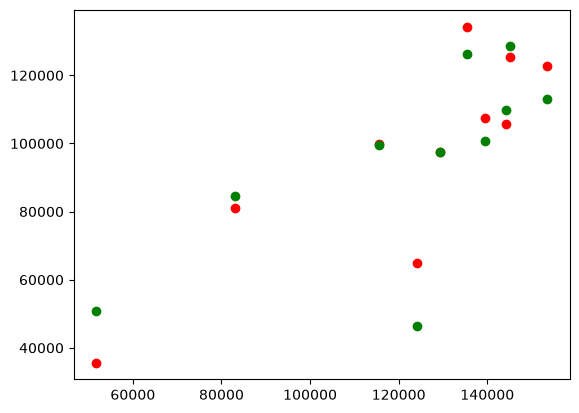

In [37]:
plt.scatter(x_test["Administration"], y_test, c = "r")
plt.scatter(x_test["Administration"], y_predict, c = "g")

# Importing the libraries

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Importing the libraries

In [39]:
df = pd.read_csv("Position_Salaries.csv")

In [40]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


# Plot the data using scatter plot

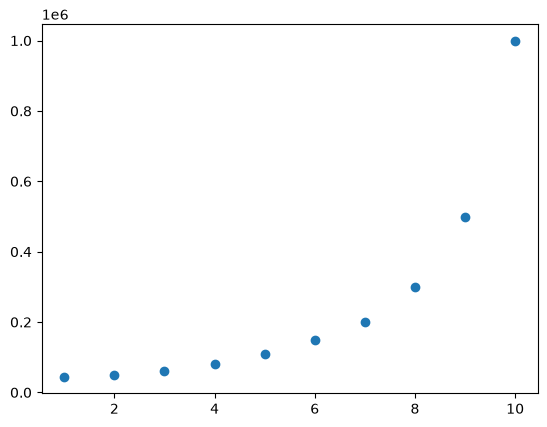

In [41]:
plt.scatter(df['Level'],df['Salary'])

In [42]:
x = df[["Level"]]
y = df["Salary"]
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# Splitting the dataset into the Training set and Test set

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 10)

In [84]:
x_test

,Level
8,9
2,3
5,6


# Fitting Linear Regression to the dataset

In [85]:
model = LinearRegression()

In [86]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[84819.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Level']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.933e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


# Predict the x_test using Linear Model

In [87]:
y_predict = model.predict(x_test)
y_predict

array([570045.04504505,  61126.12612613, 315585.58558559])

# Visualising the Linear Regression results

In [88]:
y_test

8    500000
2     60000
5    150000
Name: Salary, dtype: int64

In [89]:
y_predict

array([570045.04504505,  61126.12612613, 315585.58558559])

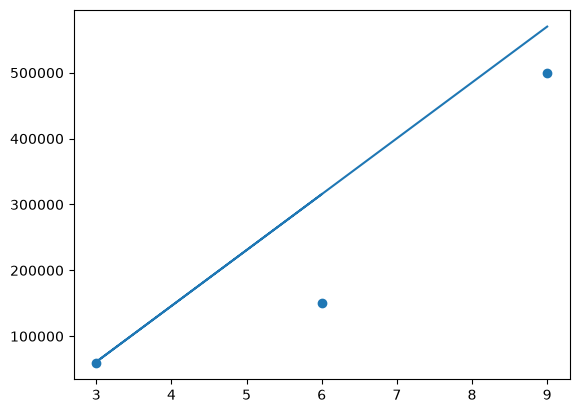

In [90]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_predict)

In [91]:
from sklearn.metrics import mean_squared_error

In [92]:
mean_squared_error(y_test,y_predict)

10775387549.711885

# Fitting Polynomial Regression to the dataset

## import  PolynomialFeatures

## create PolynomialFeatures of degree 4

## Apply fit_transform to features

## View new  Features

array([[1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01, 2.43000000e+02, 7.29000000e+02, 2.18700000e+03,
        6.56100000e+03, 1.96830000e+04, 5.90490000e+04],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01, 6.40000000e+01, 1.28000000e+02,
        2.56000000e+02, 5.12000000e+02, 1.02400000e+03],
       [1.00000000e+00, 1.00000000e+01, 1.00000000e+02, 1.00000000e+03,
        1.00000000e+04, 1.00000000e+05, 1.00000000e+06, 1.00000000e+07,
        1.00000000e+08, 1.00000000e+09, 1.00000000e+10],
       [1.00000000e+00, 8.00000000e+00, 6.40000000e+01, 5.12000000e+02,
        4.09600000e+03, 3.27680000e+04, 2.62144000e+05, 2.09715200e+06,
        1.67772160e+07, 1.34217728e+08, 1.07374182e+09],
       [1.00000000e+00, 4.00000000e+00, 1.60000000e+01, 6.40000000e+01,
        2.56000000e+02, 1.02400000e+03, 4.09600000e+03, 1.63840000e+04,
        6.55360000e+04, 2.62144000e+05, 1.04857600e+

## Fitting Polynomial Regression to the dataset

LinearRegression()

# Create Grid for higher resolution and smoother curve

# Predict the x_test using Polynomial Regression

In [22]:
x_test

,Level
8,9
5,6
0,1


# Visualising the Linear Regression results

8    500000
5    150000
0     45000
Name: Salary, dtype: int64

array([ 596551.72413793,  299568.96551724, -195402.29885057])

array([534753.92278604, 148214.11999257,  47014.83400916])

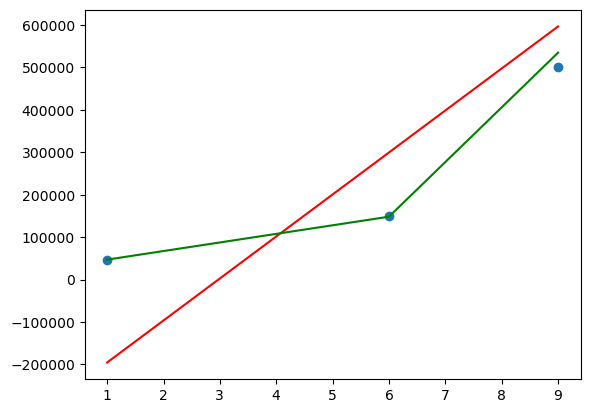

In [41]:
import numpy as np

In [50]:
new_x = np.arange(1,10,0.1).reshape(-1,1)

In [51]:
new_x

array([[1. ],
       [1.1],
       [1.2],
       [1.3],
       [1.4],
       [1.5],
       [1.6],
       [1.7],
       [1.8],
       [1.9],
       [2. ],
       [2.1],
       [2.2],
       [2.3],
       [2.4],
       [2.5],
       [2.6],
       [2.7],
       [2.8],
       [2.9],
       [3. ],
       [3.1],
       [3.2],
       [3.3],
       [3.4],
       [3.5],
       [3.6],
       [3.7],
       [3.8],
       [3.9],
       [4. ],
       [4.1],
       [4.2],
       [4.3],
       [4.4],
       [4.5],
       [4.6],
       [4.7],
       [4.8],
       [4.9],
       [5. ],
       [5.1],
       [5.2],
       [5.3],
       [5.4],
       [5.5],
       [5.6],
       [5.7],
       [5.8],
       [5.9],
       [6. ],
       [6.1],
       [6.2],
       [6.3],
       [6.4],
       [6.5],
       [6.6],
       [6.7],
       [6.8],
       [6.9],
       [7. ],
       [7.1],
       [7.2],
       [7.3],
       [7.4],
       [7.5],
       [7.6],
       [7.7],
       [7.8],
       [7.9],
       [8. ],
      

In [52]:
y_all = model1.predict(poly.fit_transform(new_x))

In [53]:
y_all

array([ 47014.83400916,  47124.23463931,  47263.16344879,  47436.17210049,
        47647.94562377,  47903.25337985,  48206.90233109,  48563.69317001,
        48978.37966438,  49455.63140477,  50000.00000001,  50615.88865094,
        51307.52494372,  52078.93663772,  52933.93017923,  53876.07164833,
        54908.66984132,  56034.76120354,  57257.09635465,  58578.12799059,
        60000.00000002,  61524.53769804,  63153.23915375,  64887.26766953,
        66727.44555756,  68674.24945041,  70727.80747738,  72887.8987336 ,
        75153.95556413,  77525.06927843,  80000.00000001,  82577.19144028,
        85254.79146293,  88030.67937423,  90902.50093334,  93867.7121241 ,
        96923.63276372, 100067.51104296, 103296.60009509, 106608.24767564,
       110000.00000001, 113469.72072985, 117015.72602001, 120636.93643462,
       124333.04641118, 128104.71179458, 131953.7557767 , 135883.39335991,
       139898.47421337, 144005.7435075 , 148214.11999257, 152534.99023116,
       156982.51749882, 1

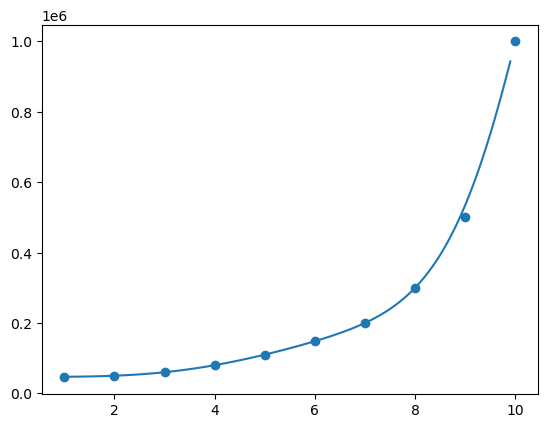

In [59]:
plt.scatter(x,y)
plt.plot(new_x,y_all)